In [2]:
pip install tensorflow numpy matplotlib --user

Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

In [4]:
# Load top 10,000 most frequent words
vocab_size = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 9s 1us/step
Training samples: 25000
Testing samples: 25000


In [5]:
print("Sample review (encoded):", X_train[0])
print("Sample label:", y_train[0])  # 1 = Positive, 0 = Negative

Sample review (encoded): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25, 100, 43, 838, 112, 50, 670, 2, 9, 35, 480, 284, 5, 150, 4, 172, 112, 167, 2, 336, 385, 39, 4, 172, 4536, 1111, 17, 546, 38, 13, 447, 4, 192, 50, 16, 6, 147, 2025, 19, 14, 22, 4, 1920, 4613, 469, 4, 22, 71, 87, 12, 16, 43, 530, 38, 76, 15, 13, 1247, 4, 22, 17, 515, 17, 12, 16, 626, 18, 2, 5, 62, 386, 12, 8, 316, 8, 106, 5, 4, 2223, 5244, 16, 480, 66, 3785, 33, 4, 130, 12, 16, 38, 619, 5, 25, 124, 51, 36, 135, 48, 25, 1415, 33, 6, 22, 12, 215, 28, 77, 52, 5, 14, 407, 16, 82, 2, 8, 4, 107, 117, 5952, 15, 256, 4, 2, 7, 3766, 5, 723, 36, 71, 43, 530, 476, 26, 400, 317, 46, 7, 4, 2, 1029, 13, 104, 88, 4, 381, 15, 297, 98, 32, 2071, 56, 26, 141, 6, 194, 7486, 18, 4, 226, 22, 21, 134, 476, 26, 480, 5, 144, 30, 5535, 18, 51, 36, 28, 224, 92, 25, 104, 4, 226, 65, 16, 38, 1334, 88, 12, 16, 283, 5, 16, 4472, 113, 103, 32, 15, 16, 5345, 19, 178, 32]
Sample label: 1


In [6]:
max_length = 200

X_train = sequence.pad_sequences(X_train, maxlen=max_length)
X_test = sequence.pad_sequences(X_test, maxlen=max_length)

print("Shape after padding:", X_train.shape)

Shape after padding: (25000, 200)


In [7]:
model = Sequential()

# Convert word index to dense vector
model.add(Embedding(input_dim=vocab_size, output_dim=128, input_length=max_length))

# LSTM layer
model.add(LSTM(128, dropout=0.2, recurrent_dropout=0.2))

# Output layer
model.add(Dense(1, activation='sigmoid'))

model.summary()

C:\Users\kulka\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [9]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 230s 700ms/step - accuracy: 0.7588 - loss: 0.4949 - val_accuracy: 0.8590 - val_loss: 0.3441
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 262s 702ms/step - accuracy: 0.8607 - loss: 0.3361 - val_accuracy: 0.8302 - val_loss: 0.3914
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 213s 679ms/step - accuracy: 0.8804 - loss: 0.2914 - val_accuracy: 0.8094 - val_loss: 0.4464
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 215s 687ms/step - accuracy: 0.9132 - loss: 0.2272 - val_accuracy: 0.8330 - val_loss: 0.4316
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 281s 747ms/step - accuracy: 0.9255 - loss: 0.1970 - val_accuracy: 0.8436 - val_loss: 0.4064


In [10]:
loss, accuracy = model.evaluate(X_test, y_test)
print("Test Accuracy:", accuracy)

782/782 ━━━━━━━━━━━━━━━━━━━━ 68s 87ms/step - accuracy: 0.8444 - loss: 0.4089
Test Accuracy: 0.8443999886512756


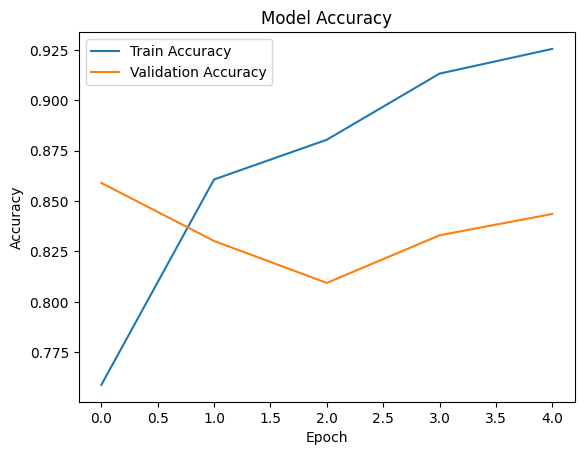

In [11]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [12]:
# Get word index
word_index = imdb.get_word_index()

# Reverse mapping
reverse_word_index = {value: key for key, value in word_index.items()}

def decode_review(encoded_review):
    return ' '.join([reverse_word_index.get(i - 3, '?') for i in encoded_review])

print(decode_review(X_test[0]))

1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step
? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? ? please give this one a miss br br ? ? and the rest of the cast rendered terrible performances the show is flat flat flat br br i don't know how michael madison could have allowed this one on his plate he almost seemed to know this wasn't going to work out and his performance was quite ? so all you madison fans give this a miss


In [13]:
sample = X_test[0].reshape(1, -1)
prediction = model.predict(sample)

if prediction[0][0] > 0.5:
    print("Positive Review 😊")
else:
    print("Negative Review 😠")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Negative Review 😠
